In [4]:
import os
os.environ["SPS_HOME"] = "FSPS/"

import fsps
sp = fsps.StellarPopulation(compute_vega_mags=False, zcontinuous=1,
                                sfh=0, logzsol=0.0, dust_type=2, dust2=0.2)

In [6]:
?sps.get_spectrum

Signature: sps.get_spectrum(zmet=None, tage=0.0, peraa=False)
Docstring:
Return spectra for the current CSP.

:param zmet: (default: None)
    The (integer) index of the metallicity to use. By default, use
    the current value of ``self.params["zmet"]``.

:param tage: (default: 0.0)
    The age of the stellar population in Gyr) for which to obtain a
    spectrum. By default, this will compute a grid of ages from
    :math:`t \approx 0` to the maximum age in the isochrones.

:param peraa: (default: False)
    If ``True``, return the spectrum in :math:`L_\odot/A`. Otherwise,
    return the spectrum in the FSPS standard
    :math:`L_\odot/\mathrm{Hz}`.

:returns wavelengths:
    The wavelength grid in Angstroms.

:returns spectrum:
    The spectrum in :math:`L_\odot/\mathrm{Hz}` or :math:`L_\odot/A`.
    If an age was provided by the ``tage`` parameter then the result
    is a 1D array with ``NSPEC`` values. Otherwise, it is a 2D array
    with shape ``(NTFULL, NSPEC)``.
File:      /Libr

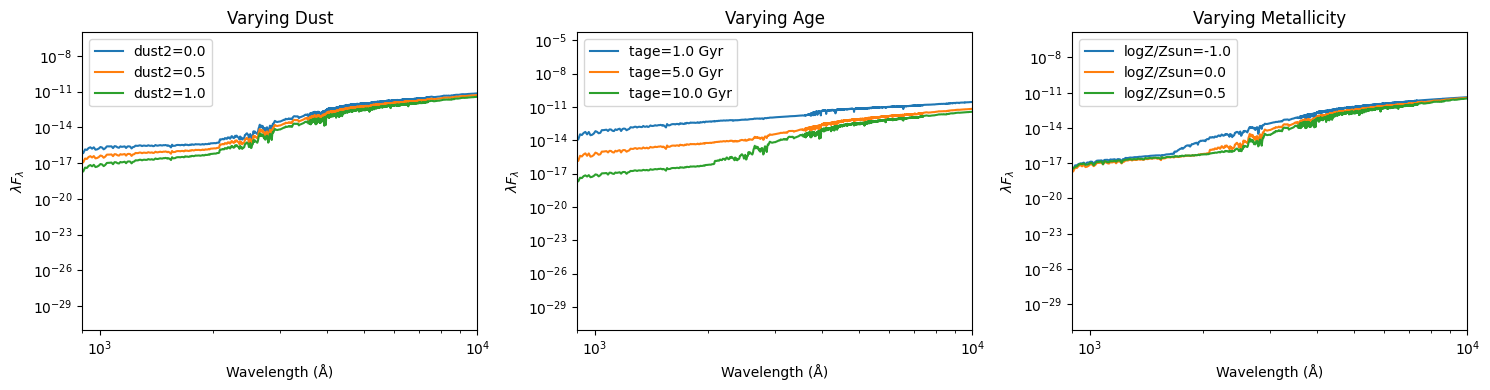

In [5]:
import fsps
import numpy as np
import matplotlib.pyplot as plt

sps = fsps.StellarPopulation(sfh=1, tau=1.0, zcontinuous=1)

wavelengths = np.logspace(3, 4.2, 1000)  # 1k-16k AA

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Vary dust2 (old stars attenuation)
for dust2 in [0.0, 0.5, 1.0]:
    sps.params['dust_type'] = 0
    sps.params['dust2'] = dust2
    lam, spec = sps.get_spectrum(tage=10.0, zmet=1)
    axes[0].loglog(lam, spec * lam, label=f'dust2={dust2}')
axes[0].set_title('Varying Dust'); axes[0].legend()

# Vary age
for tage in [1.0, 5.0, 10.0]:
    lam, spec = sps.get_spectrum(tage=tage, zmet=1)
    axes[1].loglog(lam, spec * lam, label=f'tage={tage} Gyr')
axes[1].set_title('Varying Age'); axes[1].legend()

# Vary logzsol (metallicity)
for logzsol in [-1.0, 0.0, 0.5]:
    sps.params['logzsol'] = logzsol
    lam, spec = sps.get_spectrum(tage=10.0)
    axes[2].loglog(lam, spec * lam, label=f'logZ/Zsun={logzsol}')
axes[2].set_title('Varying Metallicity'); axes[2].legend()

for ax in axes:
    ax.set_xlabel('Wavelength (Å)'); ax.set_ylabel(r'$\lambda F_\lambda$')
    ax.set_xlim(900, 1e4)
plt.tight_layout()
plt.savefig('fsps_params.png')
plt.show()


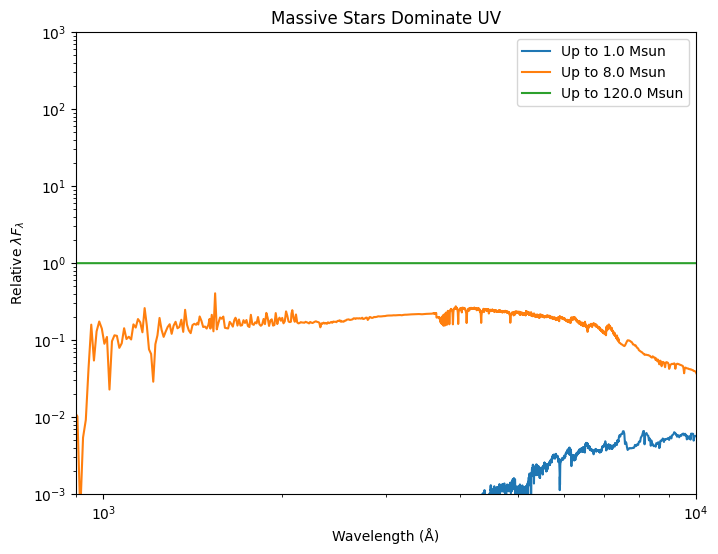

In [8]:
import fsps
import numpy as np
import matplotlib.pyplot as plt

# Use different IMF upper limits to isolate massive stars
sps_base = fsps.StellarPopulation(sfh=0, zcontinuous=1)  # SSP for clarity
wavelengths = np.logspace(3, 4.2, 1000)

plt.figure(figsize=(8, 6))
lam_base, spec_base = sps_base.get_spectrum(tage=0.01)  # Young SSP
norm = spec_base * lam_base

# Massive stars: restrict IMF upper mass
for m_upper in [1.0, 8.0, 120.0]:
    sps = fsps.StellarPopulation(sfh=0, imf_upper_limit=m_upper, zcontinuous=1)
    lam, spec = sps.get_spectrum(tage=0.01)
    plt.loglog(lam, (spec * lam / norm), label=f'Up to {m_upper} Msun')

plt.xlabel('Wavelength (Å)'); plt.ylabel(r'Relative $\lambda F_\lambda$')
plt.xlim(900, 1e4); plt.ylim(1e-3, 1e3); plt.legend(); plt.title('Massive Stars Dominate UV')
plt.loglog(); plt.savefig('fsps_stellar_masses.png')
plt.show()


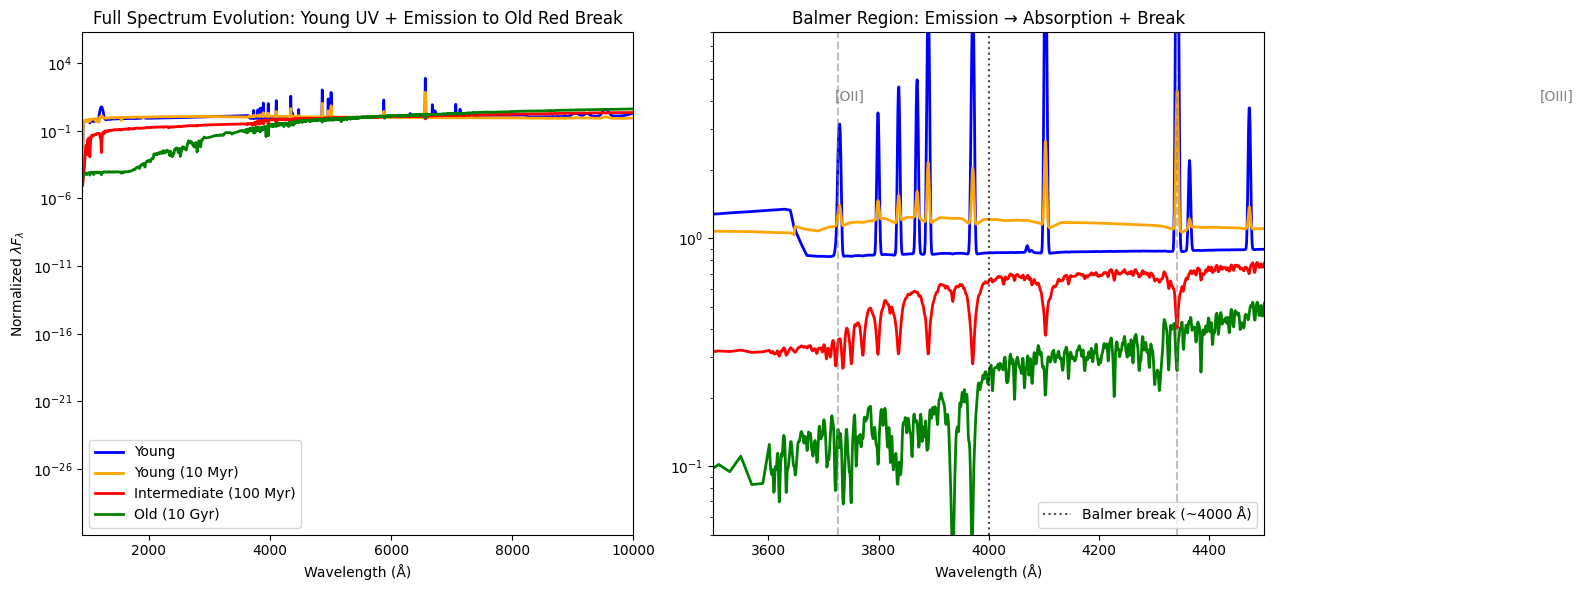

Young pop line fluxes (erg/s/cm^2):


AttributeError: 'StellarPopulation' object has no attribute 'nebline_lums'

In [43]:
import fsps
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

# Wavelengths in AA, high-res for lines
wavs = np.logspace(np.log10(900), np.log10(1e4), 5000)

# Physical constants
c = constants.c * 1e10  # cm/s

# Line wavelengths (AA)
lines = {3727: '[OII]', 6563: 'Halpha', 4341: 'Hgamma', 4861: 'Hbeta', 5007: '[OIII]'}

sps = fsps.StellarPopulation(sfh=0, zcontinuous=1)  # SSPs
sps.params['dust1'] = 0.0
sps.params['dust2'] = 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['blue', 'orange', 'red', 'green']
ages = [0.001, 0.01, 0.1, 10.0]  # 10 Myr, 100 Myr, 10 Gyr
labels = ['Young', 'Young (10 Myr)', 'Intermediate (100 Myr)', 'Old (10 Gyr)']

#lams, specs = [], []
for i, (age, col, lab) in enumerate(zip(ages, colors, labels)):
    # Nebular only for young (<100 Myr)
    if age < 0.1:
        sps.params['add_neb_emission'] = True
        sps.params['gas_logz'] = -1.5  # Gas Z
        sps.params['gas_logu'] = -2.0  # Ionization parameter [web:7]
        sps.params['logzsol'] = -1.5   # Stellar Z tied
    else:
        sps.params['add_neb_emission'] = False
        sps.params['logzsol'] = -0.5    # Higher Z for old
    
    lam, spec = sps.get_spectrum(tage=age)
    lams.append(lam)
    specs.append(spec)
    
    # Normalize lambda F_lambda at ~5500 AA (V-band)
    norm_idx = np.argmin(np.abs(lam - 5500))
    plot_spec = spec * lam / (spec[norm_idx] * 5500)
    
    ax1.semilogy(lam, plot_spec, color=col, lw=2, label=lab)
    
    # Right panel for all, but young highlighted
    ax2.semilogy(lam, plot_spec, color=col, lw=2)

ax1.set_xlabel('Wavelength (Å)')
ax1.set_ylabel(r'Normalized $\lambda F_\lambda$')
ax1.set_xlim(900, 1e4); ax1.legend()
ax1.set_title('Full Spectrum Evolution: Young UV + Emission to Old Red Break')

# Balmer break + lines zoom
ax2.set_xlim(3500, 4500)
ax2.set_ylim(0.05, 8)
ax2.axvline(4000, color='k', ls=':', alpha=0.7, label='Balmer break (~4000 Å)')
for wl in lines:
    ax2.axvline(wl, color='gray', alpha=0.5, ls='--')
ax2.text(3720, 4, '[OII]', fontsize=10, color='gray')
ax2.text(5000, 4, '[OIII]', fontsize=10, color='gray')
ax2.legend()
ax2.set_xlabel('Wavelength (Å)')
ax2.set_title('Balmer Region: Emission → Absorption + Break')

plt.tight_layout()
plt.savefig('fsps_age_sequence_fixed.png', dpi=300)
plt.show()

# Print emission line fluxes for young pop (access via sps)
print("Young pop line fluxes (erg/s/cm^2):")
sps.params['add_neb_emission'] = True
sps.params['gas_logu'] = -2.0
sps.params['gas_logz'] = -0.5
lam_y, spec_y = sps.get_spectrum(tage=0.01)
print(sps.nebline_lums)  # Line luminosities [web:7]


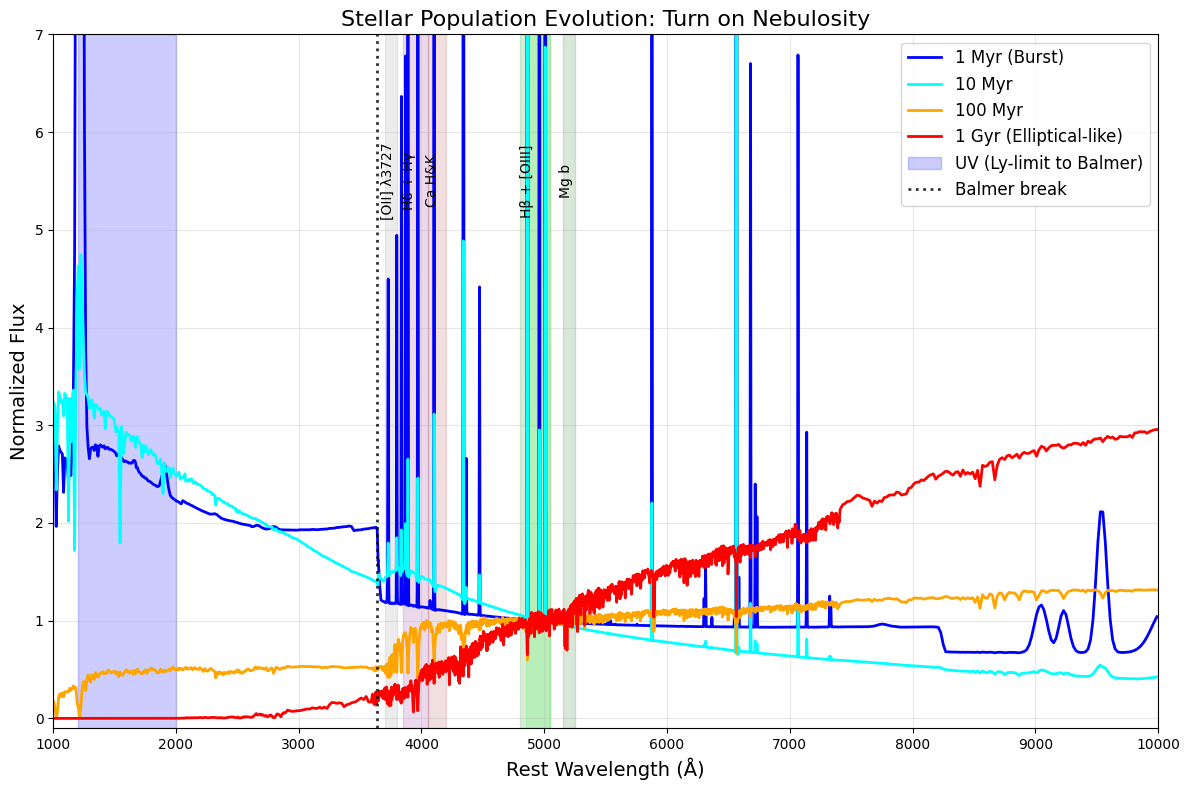

In [61]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['blue', 'cyan', 'orange', 'red']
labels = ['1 Myr (Burst)', '10 Myr', '100 Myr', '1 Gyr (Elliptical-like)']

for i in range(4):
    ll = lams[i+4]; ww = specs[i+4]
    mask = np.where((ll > 1000) & (ll < 10000))[0]
    norm_spec = ww[mask] / np.nanmedian(ww[mask[(ll[mask]>4000) & (ll[mask]<6000)]])  # V-band norm
    ax.plot(ll[mask], norm_spec, color=colors[i], lw=2, label=labels[i])

ax.set_ylim(-0.1, 7)
ax.set_xlim(1000, 10000)
ax.set_xlabel('Rest Wavelength (Å)', fontsize=14)
ax.set_ylabel('Normalized Flux', fontsize=14)
ax.set_title('Stellar Population Evolution: Turn on Nebulosity', fontsize=16)

# 1. UV region highlight (young populations dominate)
ax.axvspan(1200, 2000, alpha=0.2, color='blue', label='UV (Ly-limit to Balmer)')

# 2. Balmer break
ax.axvline(3640, color='k', ls=':', lw=2, alpha=0.8, label='Balmer break')

# 3. Prominent emission/absorption zones
line_regions = [
    (3700, 3800, '[OII] λ3727', 'gray'),      # Young emission
    (3850, 4050, 'Hδ + Hγ', 'purple'),        # Balmer series
    (4050, 4200, 'Ca H&K', 'brown'),     # Absorption grows
    (4800, 5050, 'Hβ + [OIII]', 'green'),     # Key diagnostic
    (4850, 5050, '', 'lime'),     # Nebular (young only)
    (5150, 5250, 'Mg b', 'darkgreen'),        # Metal absorption (old)
]

for left, right, label, color in line_regions:
    ax.axvspan(left, right, alpha=0.15, color=color)
    ax.text((left*3+right)/4, 5.5, label, ha='center', va='center', 
            fontsize=10, rotation=90)

# Legend and formatting
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

if 0:
    ax_inset = ax.inset_axes([0.15, 0.65, 0.3, 0.25])
    for i in [0,1]:  # Just 1 & 10 Myr
        ll = lams[i]; ww = specs[i]
        mask_uv = np.where((ll > 1200) & (ll < 2500))[0]
        norm_uv = ww[mask_uv] / np.nanmedian(ww[mask_uv])
        ax_inset.plot(ll[mask_uv], norm_uv, color=colors[i], lw=3)
    ax_inset.set_title('UV Young Dominance', fontsize=10)
    ax_inset.set_ylim(0.1, 10); ax_inset.set_yscale('log')
    ax_inset.set_xlabel('Å'); ax_inset.set_ylabel('Norm')

plt.tight_layout()
plt.savefig('fsps_ssp_evolution_pedagogical.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
len(lams)

8

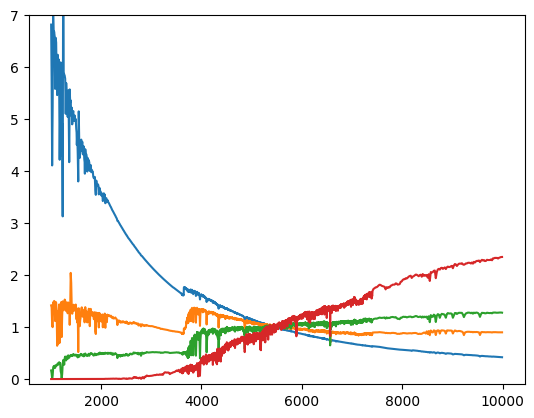

In [39]:
# 0-2 : Higher M/H at young age
# 3-5 : M/H = -2 for young, M/H = 0 for old
# 5-6 : M/H = -0.5 for both

for i in range(4):
    ll = lams[i]
    ww = specs[i]
    mask = np.where((ll>1000) & (ll<10000))[0]
    plt.plot(ll[mask], ww[mask]/np.nanmedian(ww[mask]))
    plt.ylim(-0.1,7)

In [27]:
a = (6.63e-27*1.42e9*21.1) / (4*np.pi*11.1e6*3.154e7*np.sqrt(6.28)*8.5e5) * 3*1.44e21

In [28]:
a * 9e20 / (2*(1.42e9)**2 * 1.38e-16)

np.float64(148.0919780954388)

In [29]:
a

np.float64(9.157455048703711e-17)